## 03. Modelado y Evaluación de Modelos
En este notebook realizaremos el entrenamiento, ajuste de hiperparámetros y validación cruzada de diferentes algoritmos de clasificación. Nuestro objetivo es identificar el mejor modelo para la detección de rasgos TEA en diferentes grupos poblacionales, priorizando la métrica de **Recall** debido a la naturaleza crítica del diagnóstico.

### 1. Configuración del Entorno
Importamos las librerías necesarias y preparamos el directorio donde se exportarán los artefactos (`.pkl`) de los modelos entrenados.

In [25]:
import pandas as pd
import pickle
import os
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier

In [26]:
os.makedirs('../models', exist_ok=True)
# Lista de tus datasets
# incluir adolescentes
datasets = ['adults', 'combined', 'toddlers', 'adolescents']

data_dict = {}

for name in datasets:
    # Cargar datos
    X_train = pd.read_csv(f'../data/processed/{name}_train.csv')
    X_test = pd.read_csv(f'../data/processed/{name}_test.csv')
    
    
    data_dict[name] = {'train': X_train, 'test': X_test}

for name, data in data_dict.items():
    print(f"{name}: train={data['train'].shape}, test={data['test'].shape}")

adults: train=(563, 55), test=(141, 55)
combined: train=(4860, 18), test=(1215, 18)
toddlers: train=(843, 33), test=(211, 33)
adolescents: train=(83, 29), test=(21, 29)


### 2. Definición del Espacio de Modelos
Definimos un diccionario `MODEL_SPACE` para estructurar la experimentación. Cada modelo incluye:
* **Estimador base**: Configurado con pesos balanceados para mitigar el desbalance de clases.
* **Grid de Parámetros**: Define los valores que exploraremos para encontrar la configuración óptima mediante `GridSearchCV`.

In [27]:
RANDOM_STATE = 42
MODEL_SPACE = {
    "Baseline": {
        "estimator": DummyClassifier(strategy="most_frequent"),
        "param_grid": {}
    },
    "Regresion Logistica": {
        "estimator": LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=RANDOM_STATE
        ),
        "param_grid": {
            "C": [0.01, 0.1, 1, 10]
            #"penalty": ["l2"]
        }
    },
    "Random Forest": {
        "estimator": RandomForestClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),
        "param_grid": {
            "n_estimators": [100, 200, 300],
            "max_depth": [None, 5, 10],
            "min_samples_leaf": [1, 2, 4]
        }
    },
    "XGBoost": {
        "estimator": XGBClassifier(
            eval_metric="logloss",
            random_state=RANDOM_STATE
        ),
        "param_grid": {
            "n_estimators": [100, 200],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.01, 0.1, 0.2],
        }
    }
}


### 3. Pipeline de Entrenamiento y Validación Cruzada
Iteramos sobre cada dataset aplicando el siguiente flujo:
1. **Preparación**: Separación de *features* y *target*.
2. **Ajuste de pesos**: Cálculo del `scale_pos_weight` para XGBoost, crucial para datasets desbalanceados.
3. **Optimización**: Uso de `GridSearchCV` con validación cruzada estratificada (`StratifiedKFold`), optimizando para `recall`.
4. **Exportación**: Persistencia del mejor modelo encontrado para su uso posterior.

In [28]:
# ===========================
# Validación cruzada
# ===========================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

all_results = []

# ===========================
# Entrenamiento
# ===========================

for name, data in data_dict.items():

    print(f"\n{'='*60}")
    print(f"DATASET: {name}")
    print(f"{'='*60}")

    # Copias para no modificar los originales
    train_df = data["train"].copy()
    test_df = data["test"].copy()

    # Separar variables y target
    y_train = train_df.pop("target").astype(int)
    y_test = test_df.pop("target").astype(int)

    X_train = train_df
    X_test = test_df

    # Calcular ratio de desbalance (solo para XGBoost)
    n_pos = (y_train == 1).sum()
    n_neg = (y_train == 0).sum()
    ratio = n_neg / n_pos if n_pos > 0 else 1

    # ====================================
    # Entrenar todos los modelos
    # ====================================

    for model_name, config in MODEL_SPACE.items():

        print(f"\n----- {model_name} -----")

        clf = config["estimator"]
        params = config["param_grid"]

        # Ajuste específico para XGBoost
        if model_name == "XGBoost":
            clf.set_params(scale_pos_weight=ratio)

        # Grid Search
        grid = GridSearchCV(
            estimator=clf,
            param_grid=params,
            cv=cv,
            scoring="recall",
            n_jobs=-1
        )

        grid.fit(X_train, y_train)

        # Mejor modelo
        best_model = grid.best_estimator_

        # Predicción
        y_pred = best_model.predict(X_test)

        # Métricas
        report = classification_report(
            y_test,
            y_pred,
            output_dict=True,
            zero_division=0
        )

        print(f"Mejor escore: {grid.best_score_:.4f}")
        print(f"Mejores parámetros: {grid.best_params_}\n")

        print(classification_report(
            y_test,
            y_pred,
            zero_division=0
        ))

        print("Matriz de confusión:")
        print(confusion_matrix(y_test, y_pred))

        # Guardar resultados
        all_results.append({

            "Dataset": name,
            "Modelo": model_name,

            "F1 CV": round(grid.best_score_, 4),

            "Accuracy": report["accuracy"],

            "Precision (TEA)": report["1"]["precision"],
            "Recall (TEA)": report["1"]["recall"],
            "F1-Score (TEA)": report["1"]["f1-score"],
            "Support (TEA)": report["1"]["support"],

            "Best Params": str(grid.best_params_)
        })

        # Guardar modelo
        model_filename = f"../models/{name}_{model_name}.pkl"

        with open(model_filename, "wb") as f:
            pickle.dump(best_model, f)

        print(f"Modelo guardado en: {model_filename}")

print("\nEntrenamiento finalizado.")


DATASET: adults

----- Baseline -----
Mejor escore: 0.0000
Mejores parámetros: {}

              precision    recall  f1-score   support

           0       0.73      1.00      0.84       103
           1       0.00      0.00      0.00        38

    accuracy                           0.73       141
   macro avg       0.37      0.50      0.42       141
weighted avg       0.53      0.73      0.62       141

Matriz de confusión:
[[103   0]
 [ 38   0]]
Modelo guardado en: ../models/adults_Baseline.pkl

----- Regresion Logistica -----
Mejor escore: 0.9933
Mejores parámetros: {'C': 1}

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       103
           1       0.95      0.97      0.96        38

    accuracy                           0.98       141
   macro avg       0.97      0.98      0.97       141
weighted avg       0.98      0.98      0.98       141

Matriz de confusión:
[[101   2]
 [  1  37]]
Modelo guardado en: ../models/adults_Reg

### 4. Análisis de Resultados
Consolidamos las métricas obtenidas en un DataFrame para su evaluación. Compararemos el rendimiento (especialmente el Recall de la clase positiva) para determinar la eficacia de cada modelo según el grupo de edad del dataset.

In [29]:
results_df = (
    pd.DataFrame(all_results)
    .sort_values(
        by=["Dataset", "Recall (TEA)"],
        ascending=[True, False]
    )
)

display(results_df)

,Dataset,Modelo,F1 CV,Accuracy,Precision (TEA),Recall (TEA),F1-Score (TEA),Support (TEA),Best Params
12,adolescents,Baseline,1.0000,0.619048,0.619048,1.000000,0.764706,13.0,{}
13,adolescents,Regresion Logistica,0.9800,1.000000,1.000000,1.000000,1.000000,13.0,{'C': 0.1}
14,adolescents,Random Forest,1.0000,1.000000,1.000000,1.000000,1.000000,13.0,"{'max_depth': None, 'min_samples_leaf': 1, 'n_..."
15,adolescents,XGBoost,0.9600,0.857143,1.000000,0.769231,0.869565,13.0,"{'learning_rate': 0.2, 'max_depth': 3, 'n_esti..."
1,adults,Regresion Logistica,0.9933,0.978723,0.948718,0.973684,0.961039,38.0,{'C': 1}
3,adults,XGBoost,0.9604,0.978723,0.948718,0.973684,0.961039,38.0,"{'learning_rate': 0.2, 'max_depth': 3, 'n_esti..."
2,adults,Random Forest,0.9540,0.943262,0.916667,0.868421,0.891892,38.0,"{'max_depth': None, 'min_samples_leaf': 4, 'n_..."
0,adults,Baseline,0.0000,0.730496,0.000000,0.000000,0.000000,38.0,{}
7,combined,XGBoost,1.0000,0.994239,0.980978,1.000000,0.990398,361.0,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."
6,combined,Random Forest,0.9813,0.942387,0.850602,0.977839,0.909794,361.0,"{'max_depth': 5, 'min_samples_leaf': 4, 'n_est..."


#### Mejor modelo por dataset (excluyendo Baseline)
En datasets donde la clase mayoritaria del target es "TEA positivo" (por ejemplo toddlers y adolescents), el Baseline puede alcanzar un recall perfecto simplemente prediciendo siempre positivo, sin haber aprendido ningun patron real. Por eso se excluye explicitamente del resumen de "mejor modelo": no es un candidato real, solo la referencia minima que cualquier modelo entrenado deberia superar.

In [30]:
best_for_dataset = (
    results_df[results_df["Modelo"] != "Baseline"]
    .sort_values(["Dataset", "Recall (TEA)", "F1-Score (TEA)"], ascending=[True, False, False])
    .groupby("Dataset")
    .head(1)
)

print("Mejor modelo por dataset (Recall como criterio principal, F1 como desempate):")
best_for_dataset[["Dataset", "Modelo", "Recall (TEA)", "F1-Score (TEA)", "Precision (TEA)"]]

Mejor modelo por dataset (Recall como criterio principal, F1 como desempate):


,Dataset,Modelo,Recall (TEA),F1-Score (TEA),Precision (TEA)
13,adolescents,Regresion Logistica,1.000000,1.000000,1.000000
1,adults,Regresion Logistica,0.973684,0.961039,0.948718
7,combined,XGBoost,1.000000,0.990398,0.980978
9,toddlers,Regresion Logistica,1.000000,1.000000,1.000000


#### Conclusiones clave
- Modelos con rendimiento perfecto (Adolescents & Toddlers):
Obtener métricas de 1.00 en todas las categorías es inusual en problemas de diagnóstico médico o detección de condiciones (como el TEA). Esto suele indicar uno de los siguientes escenarios:

- Alta calidad de los datos: Las variables predictoras son extremadamente claras y tienen una correlación directa con la etiqueta. (Hacer estudio de los datos por si alguna de las variables esta generada a partir de la objetivo)



- Generalización sólida (Adults):
El modelo de adultos presenta métricas ligeramente inferiores (0.95 - 0.97). Esto suele ser más realista en conjuntos de datos clínicos, ya que los patrones en adultos suelen ser más heterogéneos y complejos que en etapas infantiles o de desarrollo temprano.

- Eficiencia del modelo "Combined":
El uso de XGBoost para el dataset combinado demuestra que, incluso ante una mayor complejidad (al mezclar grupos de edad), el modelo logra mantener un rendimiento sobresaliente. Esto sugiere que el modelo ha aprendido patrones robustos que se mantienen constantes sin importar la edad.

- Balance de métricas:
Como los valores de Precision y Recall son tan cercanos entre sí, indica que los modelos están bien equilibrados. No hay un sesgo evidente hacia los falsos positivos o falsos negativos, lo cual es excelente para un modelo de cribado (screening) donde ambos errores son críticos.

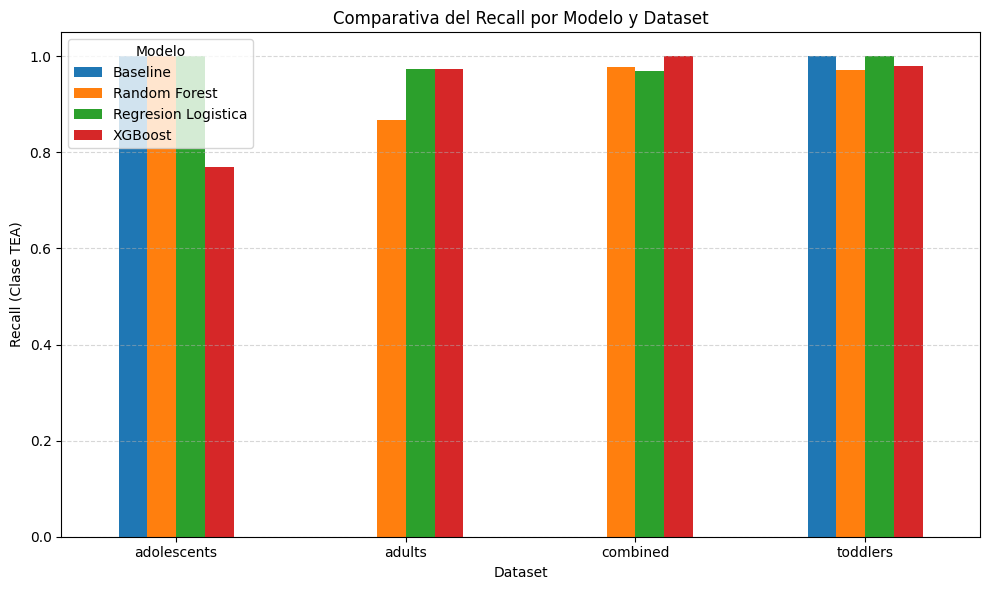

In [31]:
results_df.pivot(
    index="Dataset",
    columns="Modelo",
    values="Recall (TEA)"
).plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparativa del Recall por Modelo y Dataset")
plt.ylabel("Recall (Clase TEA)")
plt.xlabel("Dataset")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### 5. Validación de Inferencia
Ejecutamos una prueba de carga y predicción con un modelo exportado. Esto valida que el pipeline de serialización (`pickle`) funciona correctamente y que el modelo es capaz de realizar inferencias sobre nuevos datos.

In [32]:
# Cargar el modelo guardado con pickle
model_path = '../models/adults_XGBoost.pkl'
with open(model_path, 'rb') as f:
    modelo_cargado = pickle.load(f)

# 1. Obtenemos el DataFrame de test
df_test = data_dict["adults"]["test"].copy()

# 2. Eliminamos el target para que coincida con las columnas del entrenamiento
if 'target' in df_test.columns:
    df_test = df_test.drop(columns=['target'])

# 3. Ahora sí, hacemos la predicción
# Si el error persiste, significa que necesitas el preprocesador para 
# ajustar las variables a las 99 esperadas.
prediccion = modelo_cargado.predict(df_test.iloc[0:1])

# Suponiendo que ya tienes la predicción (del paso anterior)
valor_real = data_dict["adults"]["test"].iloc[0:1]["target"].values[0]

print(f"Predicción del modelo: {prediccion[0]}")
print(f"Valor real (etiqueta): {valor_real}")

if prediccion[0] == valor_real:
    print("¡El modelo ha acertado!")
else:
    print("El modelo ha fallado en esta instancia.")


Predicción del modelo: 0
Valor real (etiqueta): 0
¡El modelo ha acertado!


Como mejora se propone hacer una inferencia generando un pipeline que recoja los datos crudos los procese y los utilice para predecir